# TMA4135 - Exercise 4
Student: Magnus Ingnes Sagmo

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

## Problem 3 - Numerical Differentiation

Let 

$$u'(x) = \frac{3u(x) - 4u(x - h) + u(x - 2h)}{2h} + e(h)$$

a) _Delivered on paper_

b) _Delivered on paper_

c) Verify your results numerically as described in Slide 21 (preliminaries-bvp). Use $h = 0.1^{2-i}$, $i=0.1, · · · , 6$. Present your result as a convergence plot.


First we define the functions $u(h)$, $u'(h)$ (approximation), $e(h)$, a helper function to calculate $h$ and an approximation to $p$.

In [21]:
# Defining the functions

def u(x):
    return x * np.cos(x)


def derivative_u_approx(x, h):
    numerator = 3*u(x) - 4*u(x-h) + u(x-2*h)  # Fixed the u(x-2*h)
    denominator = 2*h
    return numerator/denominator


def e(x, h):
    # Error function, but it's based on third derivative and h^2 as per previous discussion
    return np.abs(1/3 * h**2 * (x * np.sin(x) - 3 * np.cos(x)))


def h(i):
    return 0.1 * 2**(-i)


def p(i, x):
    # Formula for p between two consecutive h values
    numerator = np.log(e(x=x, h=h(i+1)) / e(x=x, h=h(i)))
    denominator = np.log(h(i+1) / h(i))
    return numerator / denominator

Calculate $h$ and $p$ for $i=0.1, · · · , 6$

In [26]:
x = np.pi / 2

h_values = [h(i) for i in range(7)]
errors = [e(x=x, h=h_values[i]) for i in range(7)]
# p(i) is calculated for pairs, so only len(h_values) - 1
p_arr = [p(i, x=x) for i in range(7)]

Plot the results

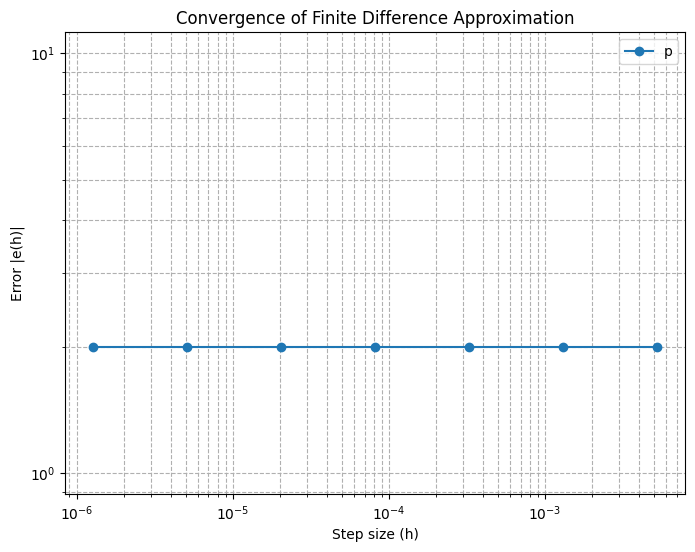

In [27]:
# Plot the convergence
plt.figure(figsize=(8, 6))
plt.loglog(errors, p_arr, label='p', marker='o')
plt.xlabel('Step size (h)')
plt.ylabel('Error |e(h)|')
plt.title('Convergence of Finite Difference Approximation')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

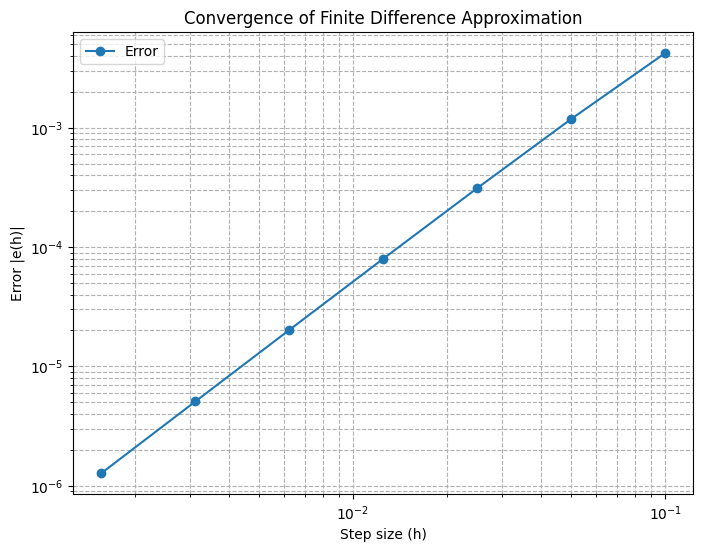

p between h[0] = 0.10000 and h[1] = 0.05000: 1.8349
p between h[1] = 0.05000 and h[2] = 0.02500: 1.9248
p between h[2] = 0.02500 and h[3] = 0.01250: 1.9640
p between h[3] = 0.01250 and h[4] = 0.00625: 1.9824
p between h[4] = 0.00625 and h[5] = 0.00313: 1.9913
p between h[5] = 0.00313 and h[6] = 0.00156: 1.9957
Average estimated order of accuracy (p): 1.9489


In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function and its derivative


def u(x):
    return x * np.cos(x)


def u_derivative_exact(x):
    return np.cos(x) - x * np.sin(x)

# Finite difference approximation


def u_derivative_approx(x, h):
    return (3*u(x) - 4*u(x - h) + u(x - 2*h)) / (2*h)


# Compute the error for different values of h
x_value = np.pi / 2
h_initial = 0.1
i_values = np.arange(0, 7)  # i from 0 to 6
h_values = h_initial * 2.0**(-i_values)  # h = 0.1 * 2^-i
errors = []

# Calculate the error for each h
for h in h_values:
    approx_derivative = u_derivative_approx(x_value, h)
    exact_derivative = u_derivative_exact(x_value)
    error = np.abs(approx_derivative - exact_derivative)
    errors.append(error)

# Plot the convergence
plt.figure(figsize=(8, 6))
plt.loglog(h_values, errors, label='Error', marker='o')
plt.xlabel('Step size (h)')
plt.ylabel('Error |e(h)|')
plt.title('Convergence of Finite Difference Approximation')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

# Calculate p values using the formula from Slide 21
p_values = []
for k in range(len(h_values) - 1):
    p_k = np.log(errors[k+1] / errors[k]) / np.log(h_values[k+1] / h_values[k])
    p_values.append(p_k)

# Print the p values
for i, p in enumerate(p_values):
    print(f"p between h[{i}] = {h_values[i]:.5f} and h[{
          i+1}] = {h_values[i+1]:.5f}: {p:.4f}")

# Average p value (approximate order of accuracy)
average_p = np.mean(p_values)
print(f"Average estimated order of accuracy (p): {average_p:.4f}")